# Lord of the Rings Name Generator

A character-level LSTM trained from scratch on hundreds of Tolkien names.
The model learns phonetic patterns from Elvish, Dwarvish, Mannish, and other naming conventions,
then generates novel names that sound like they belong in Middle-earth.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from collections import Counter

## Training Data

A comprehensive list of names from Tolkien's legendarium: The Silmarillion, The Lord of the Rings,
The Hobbit, Unfinished Tales, and other works. Includes Elves, Men, Dwarves, Hobbits, Maiar,
Valar, places, and titles.

In [2]:
NAMES = [
    # === Elves ===
    "Galadriel", "Legolas", "Elrond", "Arwen", "Thranduil", "Celeborn",
    "Glorfindel", "Erestor", "Lindir", "Haldir", "Rumil", "Orophin",
    "Celebrian", "Elladan", "Elrohir", "Cirdan", "Gildor", "Inglorion",
    # Silmarillion Elves
    "Feanor", "Fingolfin", "Finarfin", "Fingon", "Turgon", "Aredhel",
    "Idril", "Maeglin", "Ecthelion", "Eol", "Thingol", "Melian",
    "Luthien", "Beleg", "Mablung", "Daeron", "Celebrimbor", "Curufin",
    "Celegorm", "Caranthir", "Amrod", "Amras", "Maedhros", "Maglor",
    "Earendil", "Elwing", "Dior", "Nimloth", "Oropher", "Amdir",
    "Amroth", "Nimrodel", "Gwindor", "Gelmir", "Guilin", "Nerdanel",
    "Indis", "Miriel", "Finwe", "Olwe", "Elwe", "Ingwe",
    "Voronwe", "Enerdhil", "Pengolodh", "Saeros", "Nellas", "Annael",
    "Galathil", "Orodreth", "Angrod", "Aegnor", "Edrahil",
    # More Elves
    "Aranwe", "Earwen", "Elenwe", "Finduilas", "Galadhon",
    "Lenwe", "Morwe", "Nurwe", "Tathar", "Tata",
    "Irime", "Lalwen", "Anaire", "Eldalote",
    
    # === Men ===
    "Aragorn", "Boromir", "Faramir", "Denethor", "Theoden", "Eomer",
    "Eowyn", "Grima", "Hama", "Gamling", "Erkenbrand", "Elfhelm",
    "Imrahil", "Beregond", "Bergil", "Ioreth", "Forlong", "Hirluin",
    "Dervorin", "Duinhir", "Golasgil", "Angbor",
    # Numenoreans
    "Elendil", "Isildur", "Anarion", "Tar-Minyatur", "Tar-Palantir",
    "Ar-Pharazon", "Tar-Miriel", "Tar-Ancalime", "Tar-Ciryatan",
    "Tar-Atanamir", "Tar-Telperien", "Tar-Meneldur", "Tar-Aldarion",
    "Tar-Elendil", "Tar-Surion", "Tar-Calmacil",
    # Dunedain / Gondor Kings
    "Elessar", "Thorongil", "Arathorn", "Arador", "Argonui", "Arassuil",
    "Arahael", "Aranarth", "Arvedui", "Arvegil", "Argeleb",
    "Earnur", "Earnil", "Ondoher", "Narmacil", "Calimehtar",
    "Aldamir", "Eldacar", "Castamir", "Valacar", "Romendacil",
    "Hyarmendacil", "Ciryandil", "Atanatar", "Turambar", "Falastur",
    "Meneldil", "Cemendur", "Ostoher", "Tarannon",
    # Edain / First Age Men
    "Turin", "Hurin", "Morwen", "Nienor", "Beren", "Barahir",
    "Belegund", "Baragund", "Bregor", "Boromir", "Hador", "Galdor",
    "Huor", "Tuor", "Brandir", "Hunthor", "Haleth", "Haldar",
    "Marach", "Malach", "Amlach", "Bereg",
    # Rohirrim
    "Eorl", "Brego", "Aldor", "Frea", "Brytta", "Walda",
    "Folca", "Folcwine", "Fengel", "Thengel", "Helm",
    "Deorwine", "Dunhere", "Grimbold", "Guthlaf", "Herugrim",
    "Dernhelm", "Gleowine", "Fastred", "Folcred",
    
    # === Dwarves ===
    "Gimli", "Gloin", "Thorin", "Balin", "Dwalin", "Bifur",
    "Bofur", "Bombur", "Fili", "Kili", "Oin", "Ori",
    "Nori", "Dori", "Durin", "Thror", "Thrain", "Dain",
    "Nain", "Fundin", "Groin", "Farin", "Borin", "Nauglamir",
    "Telchar", "Gamil", "Azaghal", "Mim", "Ibun", "Khim",
    
    # === Hobbits ===
    "Frodo", "Samwise", "Meriadoc", "Peregrin", "Bilbo", "Drogo",
    "Primula", "Lobelia", "Otho", "Lotho", "Fredegar", "Folco",
    "Paladin", "Eglantine", "Esmeralda", "Saradoc", "Rorimac",
    "Gerontius", "Adamanta", "Isembard", "Bandobras",
    "Tobold", "Hamfast", "Gaffer", "Rosie", "Elanor",
    "Goldilocks", "Merry", "Pippin", "Fatty",
    "Smeagol", "Deagol",
    
    # === Valar and Maiar ===
    "Manwe", "Varda", "Ulmo", "Aule", "Yavanna", "Mandos",
    "Nienna", "Orome", "Vana", "Tulkas", "Nessa", "Este",
    "Lorien", "Morgoth", "Melkor", "Sauron", "Saruman",
    "Gandalf", "Radagast", "Olorin", "Curunir", "Aiwendil",
    "Alatar", "Pallando", "Tilion", "Arien", "Eonwe", "Ilmare",
    "Gothmog", "Ungoliant", "Shelob", "Thuringwethil",
    "Ossë", "Uinen", "Salmar",
    
    # === Villains / Orcs / Others ===
    "Azog", "Bolg", "Grishnakh", "Shagrat", "Gorbag", "Ugluk",
    "Lurtz", "Gothmog", "Gollum", "Wormtongue",
    "Ancalagon", "Glaurung", "Smaug", "Scatha",
    "Carcharoth", "Draugluin", "Huan",
    
    # === Places (great phonetic patterns) ===
    "Gondolin", "Nargothrond", "Doriath", "Rivendell", "Lothlorien",
    "Mirkwood", "Erebor", "Khazad-dum", "Gondor", "Rohan",
    "Mordor", "Isengard", "Orthanc", "Barad-dur", "Minas Tirith",
    "Minas Morgul", "Osgiliath", "Pelargir", "Dol Amroth",
    "Edoras", "Dunharrow", "Helms Deep", "Fangorn",
    "Valinor", "Tirion", "Alqualonde", "Formenos", "Taniquetil",
    "Numenor", "Armenelos", "Andunie", "Romenna",
    "Angband", "Utumno", "Thangorodrim",
    "Menegroth", "Himring", "Tol Sirion", "Nargothrond",
    "Amon Ereb", "Amon Rudh", "Amon Sul",
    "Tol Eressea", "Avallone", "Edhellond", "Annuminas",
    "Fornost", "Carn Dum", "Tharbad", "Lond Daer",
    "Umbar", "Harad", "Rhun", "Dorwinion",
    "Gladden", "Celebrant", "Nimrodel", "Anduin",
    "Bruinen", "Sirion", "Narog", "Gelion", "Ossiriand",
    "Beleriand", "Nevrast", "Hithlum", "Dor-lomin",
    
    # === Titles / Compound Names ===
    "Gandalf the Grey", "Gandalf the White", "Saruman the White",
    "Radagast the Brown", "Thorin Oakenshield", "Aragorn Elessar",
    "Elendil the Tall", "Isildur the Tall", "Turin Turambar",
    "Beren Erchamion", "Luthien Tinuviel", "Earendil the Mariner",
    "Feanor Spirit of Fire", "Fingolfin the Valiant",
    "Hurin Thalion", "Helm Hammerhand", "Eorl the Young",
    "Theoden Ednew", "Durin the Deathless",
    "Sauron the Deceiver", "Morgoth Bauglir",
    "Gil-galad", "Tar-Calion", "Ar-Pharazon the Golden",
]

print(f"Total names: {len(NAMES)}")
print(f"Sample: {random.sample(NAMES, 10)}")

Total names: 400
Sample: ['Haleth', 'Voronwe', 'Rhun', 'Vana', 'Merry', 'Thorin Oakenshield', 'Denethor', 'Nain', 'Andunie', 'Sauron']


## Tokenization & Dataset

Character-level tokenization with start/end tokens. Each name becomes a training sequence.

In [3]:
# Build vocabulary from all characters in the dataset
SOS = "\x02"  # start of sequence
EOS = "\x03"  # end of sequence

all_chars = sorted(set("".join(NAMES)))
chars = [SOS, EOS] + all_chars
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(all_chars)}")

def encode(name):
    return [char_to_idx[SOS]] + [char_to_idx[c] for c in name] + [char_to_idx[EOS]]

def decode(indices):
    return "".join(idx_to_char[i] for i in indices if idx_to_char[i] not in (SOS, EOS))

# Create training pairs: (input_seq, target_seq) where target is shifted by 1
encoded = [encode(name) for name in NAMES]
print(f"Example: '{NAMES[0]}' -> {encoded[0]}")

Vocabulary size: 51
Characters:  -ABCDEFGHIKLMNOPRSTUVWYabcdefghiklmnopqrstuvwyzë
Example: 'Galadriel' -> [0, 10, 26, 36, 26, 29, 42, 34, 30, 36, 1]


## Model

A 2-layer LSTM with embedding and dropout. Small enough to train in seconds on a CPU,
expressive enough to capture Tolkien's phonetic patterns.

In [4]:
class NameGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.dropout(self.embedding(x))
        out, hidden = self.lstm(emb, hidden)
        out = self.fc(self.dropout(out))
        return out, hidden

    def init_hidden(self, batch_size=1, device="cpu"):
        return (
            torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device),
            torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device),
        )

device = "cuda" if torch.cuda.is_available() else "cpu"
model = NameGenerator(vocab_size).to(device)
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Parameters: 872,435


## Training

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = 40

losses = []
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    random.shuffle(encoded)
    epoch_loss = 0

    for seq in encoded:
        inp = torch.tensor(seq[:-1], device=device).unsqueeze(0)
        tgt = torch.tensor(seq[1:], device=device).unsqueeze(0)

        hidden = model.init_hidden(device=device)
        output, _ = model(inp, hidden)
        loss = criterion(output.squeeze(0), tgt.squeeze(0))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(encoded)
    losses.append(avg_loss)

    if epoch % 1 == 0:
        print(f"Epoch {epoch:4d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

print("\nTraining complete!")

Epoch    1/40 | Loss: 1.0845 | LR: 0.003000
Epoch    2/40 | Loss: 1.0559 | LR: 0.003000
Epoch    3/40 | Loss: 1.0602 | LR: 0.003000
Epoch    4/40 | Loss: 1.0443 | LR: 0.003000
Epoch    5/40 | Loss: 1.0570 | LR: 0.003000
Epoch    6/40 | Loss: 1.0379 | LR: 0.003000
Epoch    7/40 | Loss: 1.0345 | LR: 0.003000
Epoch    8/40 | Loss: 1.0275 | LR: 0.003000
Epoch    9/40 | Loss: 1.0276 | LR: 0.003000
Epoch   10/40 | Loss: 1.0262 | LR: 0.003000
Epoch   11/40 | Loss: 1.0225 | LR: 0.003000
Epoch   12/40 | Loss: 1.0190 | LR: 0.003000
Epoch   13/40 | Loss: 1.0222 | LR: 0.003000
Epoch   14/40 | Loss: 1.0232 | LR: 0.003000
Epoch   15/40 | Loss: 1.0379 | LR: 0.003000
Epoch   16/40 | Loss: 1.0319 | LR: 0.003000
Epoch   17/40 | Loss: 1.0395 | LR: 0.003000
Epoch   18/40 | Loss: 1.0326 | LR: 0.003000
Epoch   19/40 | Loss: 1.0363 | LR: 0.003000
Epoch   20/40 | Loss: 1.0246 | LR: 0.003000
Epoch   21/40 | Loss: 1.0135 | LR: 0.003000
Epoch   22/40 | Loss: 0.9977 | LR: 0.003000
Epoch   23/40 | Loss: 1.0181 | L

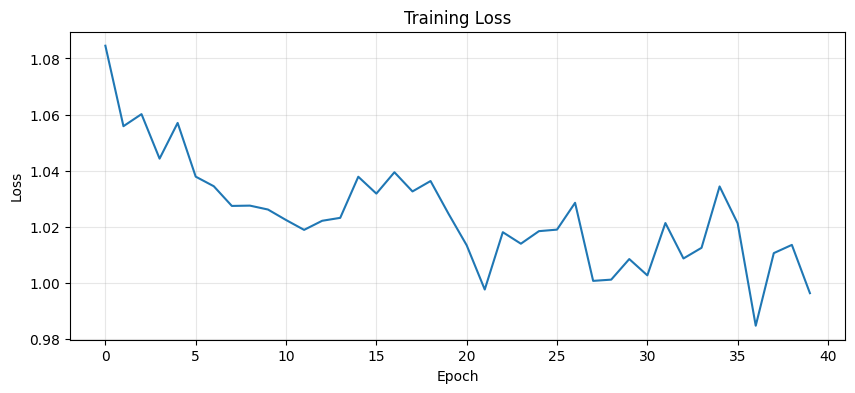

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

## Generation

Sample names with controllable temperature:
- **Low (0.3-0.5):** Conservative, close to training data
- **Medium (0.6-0.8):** Good balance of novelty and plausibility
- **High (0.9-1.2):** More creative, occasionally wild

In [8]:
@torch.no_grad()
def generate_name(model, temperature=0.7, max_len=40, start_chars=""):
    """Generate a single name. Optionally provide starting characters."""
    model.eval()
    hidden = model.init_hidden(device=device)
    
    # Feed start token
    inp = torch.tensor([[char_to_idx[SOS]]], device=device)
    output, hidden = model(inp, hidden)
    
    result = []
    
    # Feed any starting characters
    for ch in start_chars:
        idx = char_to_idx.get(ch)
        if idx is None:
            continue
        result.append(ch)
        inp = torch.tensor([[idx]], device=device)
        output, hidden = model(inp, hidden)
    
    # Generate
    for _ in range(max_len):
        logits = output.squeeze() / temperature
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs, 1).item()
        
        if idx_to_char[idx] == EOS:
            break
        result.append(idx_to_char[idx])
        inp = torch.tensor([[idx]], device=device)
        output, hidden = model(inp, hidden)
    
    return "".join(result)


def generate_names(n=10, temperature=0.7, start_chars=""):
    """Generate n unique names, filtering out exact matches from training data."""
    training_set = set(name.lower() for name in NAMES)
    results = set()
    attempts = 0
    while len(results) < n and attempts < n * 10:
        name = generate_name(model, temperature, start_chars=start_chars)
        attempts += 1
        if name and len(name) > 1 and name.lower() not in training_set:
            results.add(name)
    return sorted(results)

In [9]:
print("=" * 50)
print("  GENERATED NAMES OF MIDDLE-EARTH")
print("=" * 50)

for temp in [0.4, 0.7, 1.0]:
    print(f"\n--- Temperature {temp} ---")
    names = generate_names(15, temperature=temp)
    for name in names:
        print(f"  {name}")

  GENERATED NAMES OF MIDDLE-EARTH

--- Temperature 0.4 ---
  Celegorn
  Gondob
  Helm Hammer

--- Temperature 0.7 ---
  Amdil
  Arophin
  Celebrime
  Celegorn
  Elrach
  Sarumon
  Tar-Atanamire
  Turin Turin
  Turin thessear

--- Temperature 1.0 ---
   Sammar
   urwen
  Avanwe
  Earnhal
  Ecthil
  Galadin
  Gistil
  Inewe
  Pemerag
  Rocher
  Tar-Miryat
  Tar-niryatur
  Thrangil
  ingolfin
  latan


In [11]:
# Generate names starting with specific prefixes
print("--- Names starting with 'Ar-' ---")
for name in generate_names(8, temperature=0.7, start_chars="Ar-"):
    print(f"  {name}")

print("\n--- Names starting with 'Gal' ---")
for name in generate_names(8, temperature=0.7, start_chars="Gal"):
    print(f"  {name}")

print("\n--- Names starting with 'Th' ---")
for name in generate_names(8, temperature=0.7, start_chars="Th"):
    print(f"  {name}")

print("\n--- Names starting with 'El' ---")
for name in generate_names(8, temperature=0.7, start_chars="El"):
    print(f"  {name}")

--- Names starting with 'Ar-' ---
  Ar-Pharazon taer
  Ar-Pharazon the Goldend
  Ar-Pharazon the Goldenduil
  Ar-Pharazon the Goldendul
  Ar-Pharazon the Goldendur
  Ar-Pharazon the Grey

--- Names starting with 'Gal' ---
  Galadin
  Galadrien
  Galluin

--- Names starting with 'Th' ---
  Thangorodrier
  Thangorodril
  Theoden Ednewy
  Theoden Erebreth
  Thingor
  Thoron

--- Names starting with 'El' ---
  Elenor


In [10]:
# Big batch of names at the sweet-spot temperature
print("=" * 50)
print("  50 NAMES AT TEMPERATURE 0.7")
print("=" * 50)
names = generate_names(50, temperature=0.7)
for i, name in enumerate(names, 1):
    print(f"  {i:2d}. {name}")

  50 NAMES AT TEMPERATURE 0.7
   1. Amdil
   2. Amon Saul
   3. Amon Saur
   4. Anamire
   5. Angrog
   6. Annelob
   7. Ar-Pharazon the Goldendur
   8. Aronwe
   9. Barandir
  10. Celegor
  11. Ceregor
  12. Delegor
  13. Edralian
  14. Elorond
  15. Elrahan
  16. Elranta
  17. Eogl
  18. Galadin
  19. Isilduri
  20. Osstor
  21. Tar-Calimehtar
  22. Tar-Miniel
  23. Torong
  24. ili
